# Week 8: Decision Trees (ID3)

## Student Practice Notebook

**Name:** K V Sanjana Priya

**Roll Number:** AP24110011831

**Date:** 09-10-2026

## Learning Objectives

After completing this lab, you will be able to:

- Compute entropy and information gain, by hand and in code
- Build an ID3 decision tree by hand on a small table (the exam-style problem)
- Fit and read a `DecisionTreeClassifier`
- Explain how tree depth controls overfitting (same idea as K in Week 7 and degree in Week 6)
- Explain how a tree differs from KNN: it asks questions about *features*, it does not measure *distance*

### Why this week matters
KNN (Week 7) classified by "who is closest?". A decision tree classifies by asking a chain of yes/no questions about features, and you can read the questions. That readability is why trees are used in credit, healthcare and fraud work, and why every ensemble in Unit V is built from them.


## Part 0 — Setup

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score
import math
%matplotlib inline
np.random.seed(1)


## Part 1 — Entropy and Information Gain

**Entropy** measures how mixed a set of labels is: $H = -\sum p_i \log_2 p_i$. A pure set (all one class) has entropy 0. A 50/50 two-class set has entropy 1.

**Information gain** of splitting on an attribute = entropy before − weighted average entropy after. ID3 always picks the attribute with the highest gain.

### 1.1 Demo: entropy in code


In [29]:
def entropy(counts):
    counts = np.array(counts, dtype=float)
    p = counts[counts > 0] / counts.sum()
    return float(-np.sum(p * np.log2(p))) + 0.0

print('Pure set      [10, 0]:', entropy([10, 0]))
print('50/50 set     [5, 5] :', entropy([5, 5]))
print('Skewed set    [9, 1] :', entropy([9, 1]))


Pure set      [10, 0]: 0.0
50/50 set     [5, 5] : 1.0
Skewed set    [9, 1] : 0.4689955935892812


**Predict, then think:** which has higher entropy, a 70/30 split or a 90/10 split? Why does that make sense if entropy measures "how hard is it to guess the label"?

*Your answer:*


### Student Practice — entropy of a split

A parent node has 8 Yes and 6 No. A candidate split sends 6 samples to the left child (6 Yes, 0 No) and 8 samples to the right child (2 Yes, 6 No). Compute the entropy of the parent and the information gain of the split.


In [25]:
# Write your answer here
def entropy(yes, no):
    total = yes + no
    result = 0
    for count in [yes, no]:
        if count != 0:
            p = count / total
            result -= p * math.log2(p)

    return result
parent_entropy = entropy(8, 6)
left_entropy = entropy(6, 0)
right_entropy = entropy(2, 6)
weighted_entropy = (6 / 14) * left_entropy + (8 / 14) * right_entropy
information_gain = parent_entropy - weighted_entropy
print("Parent Entropy:", round(parent_entropy, 4))
print("Left Child Entropy:", round(left_entropy, 4))
print("Right Child Entropy:", round(right_entropy, 4))
print("Weighted Entropy:", round(weighted_entropy, 4))
print("Information Gain:", round(information_gain, 4))


Parent Entropy: 0.9852
Left Child Entropy: 0.0
Right Child Entropy: 0.8113
Weighted Entropy: 0.4636
Information Gain: 0.5216


## Part 2 — ID3 by Hand (the exam-style problem)

Classic 14-day "play tennis" table. Target: `Play`.


In [26]:
tennis = pd.DataFrame({
    'Outlook':     ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast','Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High'],
    'Wind':        ['Weak','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Weak','Weak','Strong','Strong','Weak','Strong'],
    'Play':        ['No','No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No'],
})
tennis


,Outlook,Temperature,Humidity,Wind,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [31]:

def info_gain(df, attribute, target='Play'):
    total = entropy(df[target].value_counts())
    weighted = 0
    for value, subset in df.groupby(attribute):
        weighted += (len(subset) / len(df)) * entropy(1subset[target].value_counts())
    return total - weighted
print('Root entropy:', round(entropy(tennis['Play'].value_counts()), 4))
print('Gain(Wind):', round(info_gain(tennis, 'Wind'), 4))

Root entropy: 0.9403
Gain(Wind): 0.0481


### Student Practice — find the root

1. Compute the information gain for `Outlook`, `Temperature` and `Humidity` using `info_gain`.
2. Which attribute does ID3 pick as the root?
3. For the root's branch that is **not** pure, which attribute would you split on next? (Filter `tennis` to that branch and recompute gains.)


In [32]:
# Write your answer here
attributes = ['Outlook', 'Temperature', 'Humidity']
print("Information Gain:")
for attribute in attributes:
    print(f"Gain({attribute}):", round(info_gain(tennis, attribute), 4))
root = max(attributes, key=lambda attr: info_gain(tennis, attr))
print("\nRoot attribute:", root)
for value, subset in tennis.groupby(root):
    print(f"\n{root} = {value}")
    if subset['Play'].nunique() > 1:
        remaining = [attr for attr in attributes if attr != root]
        for attribute in remaining:
            print(f"Gain({attribute}):", round(info_gain(subset, attribute), 4))
        next_split = max(remaining,key=lambda attr: info_gain(subset, attr))
        print("Next split:", next_split)
    else:
        print("Pure branch")

Information Gain:
Gain(Outlook): 0.2467
Gain(Temperature): 0.0292
Gain(Humidity): 0.1518

Root attribute: Outlook

Outlook = Overcast
Pure branch

Outlook = Rain
Gain(Temperature): 0.02
Gain(Humidity): 0.02
Next split: Temperature

Outlook = Sunny
Gain(Temperature): 0.571
Gain(Humidity): 0.971
Next split: Humidity


**Reflection:** `Overcast` became a leaf immediately. In your own words, why does a pure branch need no further splitting?

*Your answer:*


## Part 3 — `DecisionTreeClassifier` on Iris

Same Iris split as Week 7, so you can compare directly. Note: **trees do not need feature scaling**, because they compare a feature to a threshold, not distances between points. That is a real difference from KNN.


Test accuracy: 0.9555555555555556


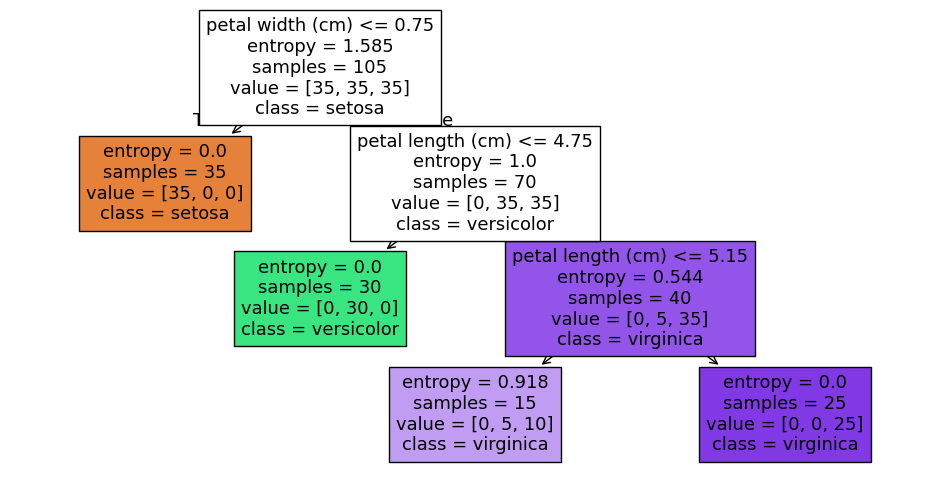

In [33]:
iris = load_iris(as_frame=True)
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)
tree = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=1)
tree.fit(X_train, y_train)
print('Test accuracy:', accuracy_score(y_test, tree.predict(X_test)))
plt.figure(figsize=(12, 6))
plot_tree(tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()


### Student Practice — depth sweep

Sweep `max_depth` from 1 to 15. Record train and test accuracy for each, plot both, and report the depth with the best test accuracy.


 Max Depth  Train Accuracy  Test Accuracy
         1        0.675000       0.633333
         2        0.950000       0.966667
         3        0.958333       1.000000
         4        0.975000       1.000000
         5        0.991667       1.000000
         6        1.000000       1.000000
         7        1.000000       1.000000
         8        1.000000       1.000000
         9        1.000000       1.000000
        10        1.000000       1.000000
        11        1.000000       1.000000
        12        1.000000       1.000000
        13        1.000000       1.000000
        14        1.000000       1.000000
        15        1.000000       1.000000

Best depth: 3
Best test accuracy: 1.0


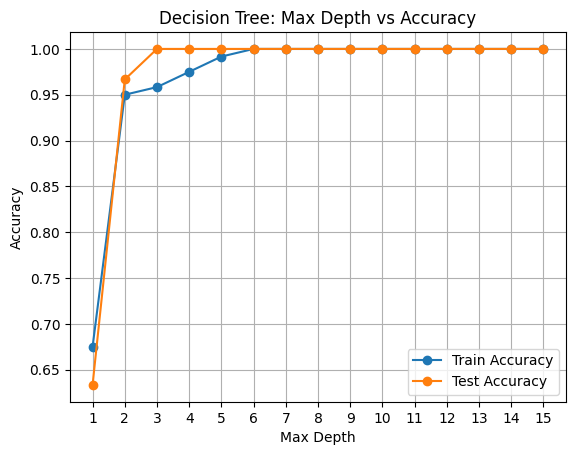

In [35]:
# Write your answer here
iris = load_iris()
X = iris.data
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
depths = range(1, 16)
train_acc = []
test_acc = []
for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))
results = pd.DataFrame({'Max Depth': depths,'Train Accuracy': train_acc,'Test Accuracy': test_acc})
print(results.to_string(index=False))
best_index = test_acc.index(max(test_acc))
print("\nBest depth:", list(depths)[best_index])
print("Best test accuracy:", round(test_acc[best_index], 4))
plt.plot(depths, train_acc, marker='o', label='Train Accuracy')
plt.plot(depths, test_acc, marker='o', label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Max Depth vs Accuracy')
plt.xticks(list(depths))
plt.legend()
plt.grid(True)
plt.show()


**Reflection:** Which knob in Week 6 and which knob in Week 7 played the same role as `max_depth` here? What happens at each extreme?

*Your answer:*


# Mini Project A: Digits, Again (Image Track — continuing from Week 7)

Last week KNN reached about 98% on the digits dataset. Now fit a decision tree on the **same split** and ask two new questions: how does it compare, and **which pixels does the tree actually use?**


In [36]:
digits = load_digits()
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    digits.data, digits.target, test_size=0.3, random_state=1, stratify=digits.target)

# KNN baseline from Week 7 (scaled, K=3)
sc = StandardScaler().fit(Xd_train)
knn = KNeighborsClassifier(n_neighbors=3).fit(sc.transform(Xd_train), yd_train)
print('KNN  test accuracy:', accuracy_score(yd_test, knn.predict(sc.transform(Xd_test))))


KNN  test accuracy: 0.9796296296296296


### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on the **unscaled** `Xd_train`. Print test accuracy. (Why is no scaling needed?)
2. Try `max_depth` values 3, 6, 10 and report test accuracy for each.
3. Take `tree.feature_importances_` (64 values), reshape to 8×8 and show it with `plt.imshow`. Which region of the image does the tree rely on?


In [37]:
# Write your answer here
digits = load_digits()
X = digits.data
y = digits.target
Xd_train, Xd_test, yd_train, yd_test = train_test_split(X, y, test_size=0.2, random_state=1)
tree = DecisionTreeClassifier(criterion='entropy', random_state=1)
tree.fit(Xd_train, yd_train)
pred = tree.predict(Xd_test)
print("Test accuracy:", accuracy_score(yd_test, pred))

Test accuracy: 0.9027777777777778


In [39]:

for depth in [3, 6, 10]:
    model = DecisionTreeClassifier(criterion='entropy',max_depth=depth,random_state=1)
    model.fit(Xd_train, yd_train)
    pred = model.predict(Xd_test)
    print(f"Max depth {depth}: Test accuracy = {accuracy_score(yd_test, pred):.4f}")

Max depth 3: Test accuracy = 0.5250
Max depth 6: Test accuracy = 0.8583
Max depth 10: Test accuracy = 0.9028


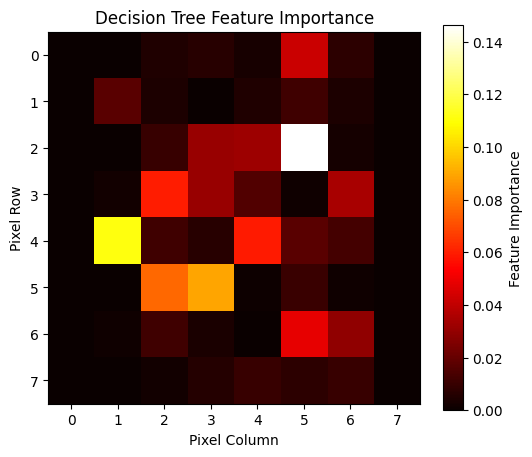

In [40]:

importance = tree.feature_importances_.reshape(8, 8)
plt.figure(figsize=(6, 5))
plt.imshow(importance, cmap='hot', interpolation='nearest')
plt.colorbar(label='Feature Importance')
plt.title('Decision Tree Feature Importance')
plt.xlabel('Pixel Column')
plt.ylabel('Pixel Row')
plt.show()

**Reflection:** Is the tree more or less accurate than KNN on digits? Offer one reason, using what the importance map shows you.

*Your answer:*


# Mini Project B: Reading a Tree on Text (NLP Track — continuing from Week 7)

Same six labeled sentences and same bag-of-words vectors as Week 7. A tree gives you something KNN cannot: **the words it chose to split on.**


In [48]:
sentences = [
    'the cricket team won the match',
    'the batsman scored a century today',
    'chop the onions and boil the pasta',
    'add salt and simmer the curry',
    'the new phone has a faster processor',
    'the laptop battery lasts all day',
]
labels = ['sports', 'sports', 'cooking', 'cooking', 'tech', 'tech']
vocab = sorted(set(w for s in sentences for w in s.lower().split()))
def to_vector(sentence, vocab):
    words = sentence.lower().split()
    return np.array([words.count(w) for w in vocab])
X_text = np.array([to_vector(s, vocab) for s in sentences])

### Student Practice

1. Fit a `DecisionTreeClassifier(criterion='entropy', random_state=1)` on `X_text`, `labels`.
2. Print the tree with `export_text(tree, feature_names=vocab)`. Which words does it split on?
3. Predict the topic of `'the striker scored a goal'` and of your own ambiguous sentence from Week 7.


In [44]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.feature_extraction.text import CountVectorizer

In [47]:
# Write your answer here
vectorizer = CountVectorizer(vocabulary=vocab)sw
tree = DecisionTreeClassifier(criterion='entropy', random_state=1)
tree.fit(X_text, labels)
print(export_text(tree, feature_names=list(vocab)))
sentence = ['the striker scored a goal']
X_new = vectorizer.transform(sentence)
prediction = tree.predict(X_new)
print("Predicted topic:", prediction[0])
ambiguous_sentence = ['the team won the match']
X_ambiguous = vectorizer.transform(ambiguous_sentence)
print("Ambiguous sentence prediction:", tree.predict(X_ambiguous)[0])

|--- and <= 0.50
|   |--- has <= 0.50
|   |   |--- laptop <= 0.50
|   |   |   |--- class: sports
|   |   |--- laptop >  0.50
|   |   |   |--- class: tech
|   |--- has >  0.50
|   |   |--- class: tech
|--- and >  0.50
|   |--- class: cooking

Predicted topic: sports
Ambiguous sentence prediction: sports


**Reflection:** If you added 3 more sentences per topic, would you expect the same split words? What does that tell you about trusting a tree trained on very little data?

*Your answer:*


In [51]:
sentences = [
    'the cricket team won the match',
    'the batsman scored a century today',
    'chop the onions and boil the pasta',
    'add salt and simmer the curry',
    'the new phone has a faster processor',
    'the laptop battery lasts all day',
    'the climate looks to be rainy'
]
labels = ['sports', 'sports', 'cooking', 'cooking', 'tech', 'tech','weather']
vocab = sorted(set(w for s in sentences for w in s.lower().split()))
def to_vector(sentence, vocab):
    words = sentence.lower().split()
    return np.array([words.count(w) for w in vocab])
X_text = np.array([to_vector(s, vocab) for s in sentences])

In [53]:
tree = DecisionTreeClassifier(criterion='entropy', random_state=1)
tree.fit(X_text, labels)
print(export_text(tree, feature_names=list(vocab)))
sentence = 'the striker scored a goal'
X_new = to_vector(sentence, vocab).reshape(1, -1)
print("Predicted topic:", tree.predict(X_new)[0])
ambiguous_sentence = 'the team won the match'
X_ambiguous = to_vector(ambiguous_sentence, vocab).reshape(1, -1)
print("Ambiguous sentence prediction:", tree.predict(X_ambiguous)[0])

|--- and <= 0.50
|   |--- climate <= 0.50
|   |   |--- all <= 0.50
|   |   |   |--- new <= 0.50
|   |   |   |   |--- class: sports
|   |   |   |--- new >  0.50
|   |   |   |   |--- class: tech
|   |   |--- all >  0.50
|   |   |   |--- class: tech
|   |--- climate >  0.50
|   |   |--- class: weather
|--- and >  0.50
|   |--- class: cooking

Predicted topic: sports
Ambiguous sentence prediction: sports


In [54]:
sentences = [
    'the cricket team won the match',
    'the batsman scored a century today',
    'chop the onions and boil the pasta',
    'add salt and simmer the curry',
    'the new phone has a faster processor',
    'the laptop battery lasts all day'
]
labels = ['sports', 'sports', 'cooking', 'cooking', 'tech', 'tech']
def train_tree(sentences, labels):
    vocab = sorted(set(w for s in sentences for w in s.lower().split()))
    def to_vector(sentence):
        words = sentence.lower().split()
        return [words.count(w) for w in vocab]
    X = np.array([to_vector(s) for s in sentences])
    tree = DecisionTreeClassifier(criterion='entropy', random_state=1)
    tree.fit(X, labels)
    print(export_text(tree, feature_names=vocab))
print("Before adding sentences:")
train_tree(sentences, labels)
sentences.extend([
    'the bowler took three wickets',
    'the team scored a goal',
    'boil the rice in water',
    'add spices to the soup',
    'the phone has a new camera',
    'the computer has a fast processor'
])
labels.extend([
    'sports', 'sports',
    'cooking', 'cooking',
    'tech', 'tech'
])
print("\nAfter adding sentences:")
train_tree(sentences, labels)

Before adding sentences:
|--- and <= 0.50
|   |--- has <= 0.50
|   |   |--- laptop <= 0.50
|   |   |   |--- class: sports
|   |   |--- laptop >  0.50
|   |   |   |--- class: tech
|   |--- has >  0.50
|   |   |--- class: tech
|--- and >  0.50
|   |--- class: cooking


After adding sentences:
|--- has <= 0.50
|   |--- laptop <= 0.50
|   |   |--- boil <= 0.50
|   |   |   |--- add <= 0.50
|   |   |   |   |--- class: sports
|   |   |   |--- add >  0.50
|   |   |   |   |--- class: cooking
|   |   |--- boil >  0.50
|   |   |   |--- class: cooking
|   |--- laptop >  0.50
|   |   |--- class: tech
|--- has >  0.50
|   |--- class: tech



## Summary

| What we did | Why it matters |
|---|---|
| Entropy and information gain | The rule ID3 uses to choose every split |
| ID3 by hand on the tennis table | Exam-style problem, show your working |
| `DecisionTreeClassifier` and depth sweep | Third version of the bias-variance knob (degree, K, depth) |
| Mini A: digits | Tree vs KNN on the same data, plus which pixels matter |
| Mini B: text | A tree you can read, and why tiny data makes it fragile |

**Next week:** Naive Bayes, a probabilistic classifier. Same digits and sentences again.
